# Example: dielectric response of water

In this notebook, we present a full example comparing the standard method and the virtual cavity method to compute the dielectric response of water.

### Run simulation

We first run a simulation of water (TIP4P-EW forcefield) using OpenMM at T = 320 K and atmospheric pressure. The simulation box contains 6000 molecules. The system is equilibrated during 1000 ps and run for 2000 ps.

For that, you can either dowload the trajectory from ?.
Or you can execute the file `run_water.py`. This will generate a .dcd file weighing approximately 280 MB. On a single CPU, this simulation can take of the order of 12 h. On a GPU, it will be completed after 15 min.

### Extract dipoles orientations and positions

We first compute, for each saved time step, the orientation of the dipole moment of each molecule as well a the position of the center of charge. We also extract the size of the simulation box for each time step.
All these quantities are saved in a .npz file.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import dielcav

In [4]:
ref = '320K_1'

In [ ]:
dielcav.compute_dipoles(f'./in/water.tpr', f'./out/trajectory_{ref}.dcd', savefile=f'out/dipoles_{ref}')

### Computing the dielectric constant with the standard method

The dielectric constant can be obtained from the variance of the total dipole moment of the simulation box $\vec{M} = \sum_i \vec{\mu}_i$. For this we first compute the finite-size Kirkwood correlation factor $G_K = \langle M^2\rangle/(N\mu^2)$

In [5]:
fname = rf'./out/dipoles_{ref}'
with np.load(f'{fname}.npz') as data:
    dips = data['dipoles']
    cell = data['cell']
    
imax, Nmol, Ndip_mol = dips.shape[:3]
dips = dips.reshape(len(dips), Nmol*Ndip_mol, 3)
dips_norm = np.linalg.norm(dips, axis=-1)
M = np.sum(dips, axis=1)
G_K = np.mean(np.sum(M[::5]**2, axis=-1))/(Nmol*np.mean(dips_norm)**2)
print(f'The finite-size Kirkwood factor is G_K = {G_K}')

The finite-size Kirkwood factor is G_K = 3.576275608768224


The dielectric constant is given by $\epsilon = 1 + \lambda G_K$ with $\lambda = \mu^2/(3\epsilon_0k_BTv)$

In [6]:
mu = np.mean(dips_norm)*1.6e-19*1e-10 # dipole moment in C.m
T = 320 # temperature in Kelvin
epsilon_0 = 8.85e-12 # vacuum permittivity
k_B = 1.38e-23 # Boltzmann constant
v = np.mean(cell[:,0]*cell[:,1]*cell[:,2])/Nmol # molecular volume (in A^3)
lambda_ = (mu**2*1e30)/(3*epsilon_0*k_B*T*v)
epsilon = 1 + lambda_*G_K
print(f'The dielectric constant is {epsilon}')

The dielectric constant is 61.07005232286669


### Computing the dielectric constant with the cavity method

Let us compute the r-dependent Kirkwood correlation factor which includes dipolar cross-correlation limited to a sphere of radius r around each molecule. Computing this quantity is costly because for each timeframe cross-correlations have to be computed for each molecule in the box. This can be parallelized between timeframes. The result for each timeframe is saved in a separate .txt file which which makes it possible to stop and restart the computation. At the end, the results are compiled in a .npz file.

In [ ]:
a = np.max(cell[:,0]) # box size (in A)
bins = np.concatenate((np.arange(0, a//2, 0.5), np.arange(a//2, a, 1.0)))
dielcav.static_cross_correlations(f'./out/dipoles_{ref}', Li0_step=5, bins=bins, savefolder=f'./out/static_cross_corr_{ref}/', N_threads=1, recompute=True)

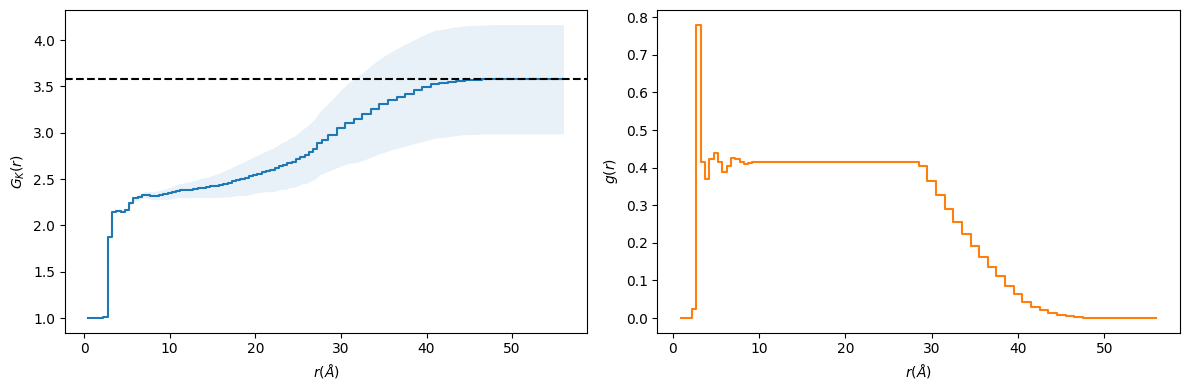

In [9]:
r, gkr, gkr_std, gr, Phi = dielcav.compute_static_gk_r(f'./out/static_cross_corr_{ref}')
factor_uncertainty = 2/np.sqrt(100) # ~ 100 relaxation times were simulated

fig, axs = plt.subplots(1,2,figsize=(12,4))
axs[0].step(r, gkr, where='mid', label='G_K(r)', c='C0')
axs[0].fill_between(r, gkr + gkr_std*factor_uncertainty, gkr - gkr_std*factor_uncertainty, color='C0', alpha=0.1, lw=0.)
axs[1].step(r[1:], gr[1:], where='mid', label='g(r)', c='C1')
axs[0].set_xlabel(r'$r (\AA)$')
axs[1].set_xlabel(r'$r (\AA)$')
axs[0].set_ylabel(r'$G_K(r)$')
axs[1].set_ylabel(r'$g(r)$')
axs[0].axhline(G_K, ls='--', c='k')
plt.tight_layout()

The r-dependent Kirkwood correlation factor display a two steps increase: a first increase corresponding to the first few neigbouring molecules and a second increase with a maximum rate at the half box size. The final value corresponds to the finite system Kirkwood factor $G_\mathrm{K}$ found above (shown here as a black dashed line).
This second increase is due to the effect of electrostatic BCs and can be estimated thanks to the work of Caillol (JCP 1992)

In [10]:
g_K_PCB = 1/(3*lambda_)*(epsilon-1)**2/epsilon*(Phi/np.max(Phi))
g_K = (2*epsilon+1)/(3*epsilon)*G_K

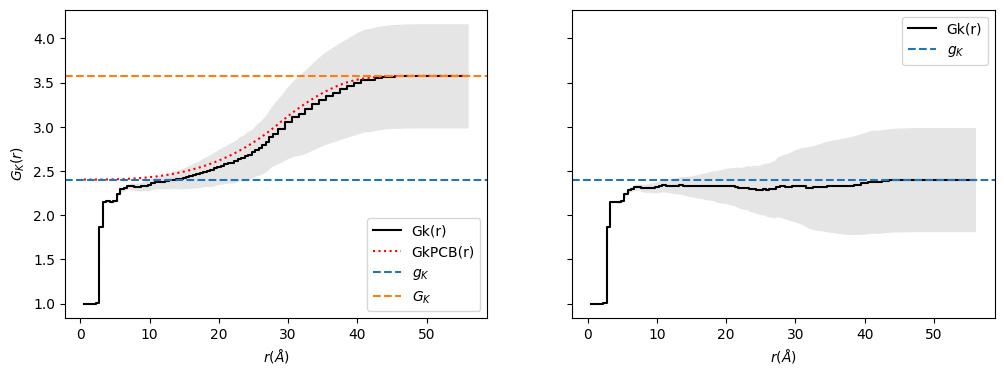

In [11]:
fig, axs = plt.subplots(1,2, sharey=True,figsize=(12,4))

axs[0].step(r, gkr, where='mid', label='Gk(r)', c='k')
axs[0].fill_between(r, gkr + gkr_std*factor_uncertainty, gkr - gkr_std*factor_uncertainty, color='k', alpha=0.1, lw=0.)
axs[0].plot(r, g_K + g_K_PCB, label='GkPCB(r)', c='r', ls=':')
axs[0].axhline(g_K, ls='--', c='C0', label=r'$g_K$')
axs[0].axhline(G_K, ls='--', c='C1', label=r'$G_K$')

axs[1].step(r, gkr - g_K_PCB, where='mid', label='Gk(r)', c='k')
axs[1].fill_between(r, gkr + gkr_std*factor_uncertainty - g_K_PCB, gkr - gkr_std*factor_uncertainty - g_K_PCB, color='k', alpha=0.1, lw=0.)
axs[1].axhline(g_K, ls='--', c='C0', label=r'$g_K$')
axs[0].set_xlabel(r'$r (\AA)$')
axs[1].set_xlabel(r'$r (\AA)$')
axs[0].set_ylabel(r'$G_K(r)$')
axs[0].legend()
axs[1].legend()

In the plot shown above, the infinite Kirkwood correlation factor $g_K$ was deduced from the determination of $G_K$. This method is not very precise because of the uncertainty associated with $G_K$.
In the cavity method, we chose a radius $r_c$ so that $g_K\approx G_K(r_c)$. This radius has to be large enough so that the short range dipolar cross correlation are included but small enougth compared to the simulation box size so that it does not include the effect of electrostatic BCs. The value of $r_c$ is system dependent.

In the present case, $r_c = 8-10 A$ seems to be a good tradeoff. The dielectric constant can be obtained by inverting the equation $(\epsilon-1)(2\epsilon+1)/\epsilon = 3\lambda g_K$

In [12]:
r_c = 9 # cavity radius
g_K_cav = np.interp(r_c, r, gkr)
print(f'The infinite-size Kirkwood factor is {g_K_cav}')
epsilon_cav = np.roots([2, -1-3*lambda_*g_K_cav, -1])[0]
print(f'The dielectric constant is {epsilon_cav}')
g_K_PCB_cav = 1/(3*lambda_)*(epsilon_cav-1)**2/epsilon_cav*(Phi/np.max(Phi))
G_K_cav = (3*epsilon_cav)/(2*epsilon_cav+1)*g_K_cav

The infinite-size Kirkwood factor is 2.3323924203328112
The dielectric constant is 59.273593708226684


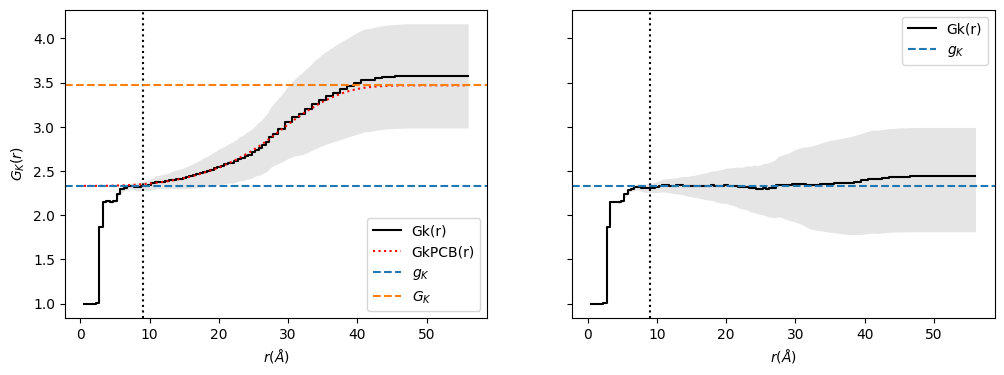

In [13]:
fig, axs = plt.subplots(1,2, sharey=True,figsize=(12,4))

axs[0].axvline(r_c, ls=':', c='k')
axs[1].axvline(r_c, ls=':', c='k')

axs[0].step(r, gkr, where='mid', label='Gk(r)', c='k')
axs[0].fill_between(r, gkr + gkr_std*factor_uncertainty, gkr - gkr_std*factor_uncertainty, color='k', alpha=0.1, lw=0.)
axs[0].plot(r, g_K_cav + g_K_PCB_cav, label='GkPCB(r)', c='r', ls=':')
axs[0].axhline(g_K_cav, ls='--', c='C0', label=r'$g_K$')
axs[0].axhline(G_K_cav, ls='--', c='C1', label=r'$G_K$')

axs[1].step(r, gkr - g_K_PCB_cav, where='mid', label='Gk(r)', c='k')
axs[1].fill_between(r, gkr + gkr_std*factor_uncertainty - g_K_PCB, gkr - gkr_std*factor_uncertainty - g_K_PCB, color='k', alpha=0.1, lw=0.)
axs[1].axhline(g_K_cav, ls='--', c='C0', label=r'$g_K$')
axs[0].set_xlabel(r'$r (\AA)$')
axs[1].set_xlabel(r'$r (\AA)$')
axs[0].set_ylabel(r'$G_K(r)$')
axs[0].legend()
axs[1].legend()

### Computing the dipole dynamics with the standard method

Let use compute the self dipole correlation function.

In [ ]:
dielcav.correlation_self(f'./out/dipoles_{ref}', Ndit=150, Li0_step=1, save=True)

Text(0.5, 1.0, 'Self dipole correlation function')

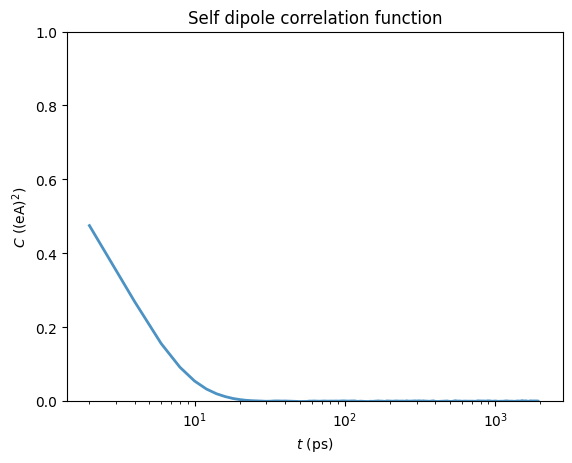

In [15]:
t_self, c_self = np.loadtxt(f'./out/dipoles_{ref}_self_corr.txt').T
plt.plot(t_self[1:], c_self[1:]/c_self[0], alpha=0.8, lw=2.)
plt.ylim((0,1))
plt.xscale('log')
plt.ylabel(r'$C$ ((eA)$^2$)')
plt.xlabel(r'$t$ (ps)')
plt.title('Self dipole correlation function')

Note that due to the large save step used in this simulation, the short time dynamic is missing.

In order to obtain the dielectric response, the need to compute the correlation function of the total dipole moment of the simulation box. 

Text(0.5, 1.0, 'Total dipole correlation function')

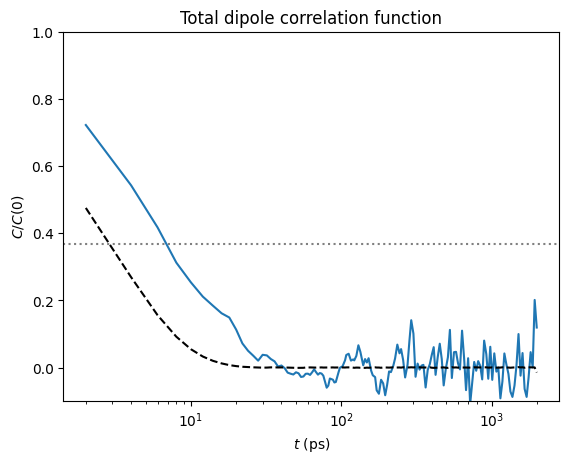

In [16]:
t_tot, c_tot = dielcav.correlation_total_box(f'./out/dipoles_{ref}', Ndit=150, Li0_step=1, save=False)
plt.plot(t_tot[1:], c_tot[1:]/c_tot[0], c='C0')
plt.plot(t_self[1:], c_self[1:]/c_self[0], c='k', ls='--')
plt.axhline(np.exp(-1), ls=':', c='grey')
plt.ylim((-0.1,1))
plt.xscale('log')
plt.ylabel(r'$C/C(0)$')
plt.xlabel(r'$t$ (ps)')
plt.title('Total dipole correlation function')

The total dipole correlation function is directly related to the dielectric response. But it is very sensitive to noise, hence the very long simulation time used here compared to the molecular relaxation time to obtain a reliable decorrelation.

### Computing the dipole dynamics with the cavity method

Let us apply the cavity method to the determination of the dielectric response. 

In [17]:
dit_val = np.array([0,1,2,4,8,16,32,64,128,256])
dielcav.dynamic_cross_correlations(f'./out/dipoles_{ref}', Li0_step=50, dit_val=dit_val, bins=bins, savefolder=f'./out/dyn_cross_corr_{ref}/', N_threads=1, recompute=False)

[0, 100, 1000, 1050, 1100, 1150, 1200, 1250, 1300, 1350, 1400, 1450, 150, 1500, 1550, 1600, 1650, 1700, 200, 250, 300, 350, 400, 450, 50, 500, 550, 600, 650, 700, 750, 800, 850, 900, 950]  already done
[]  todo
./out/dyn_cross_corr_320K_1/
35  files


In [19]:
r, t, gkrt = dielcav.compute_dynamic_gk_r(f'out/dyn_cross_corr_{ref}')

Text(0.5, 0, '$t$ (ps)')

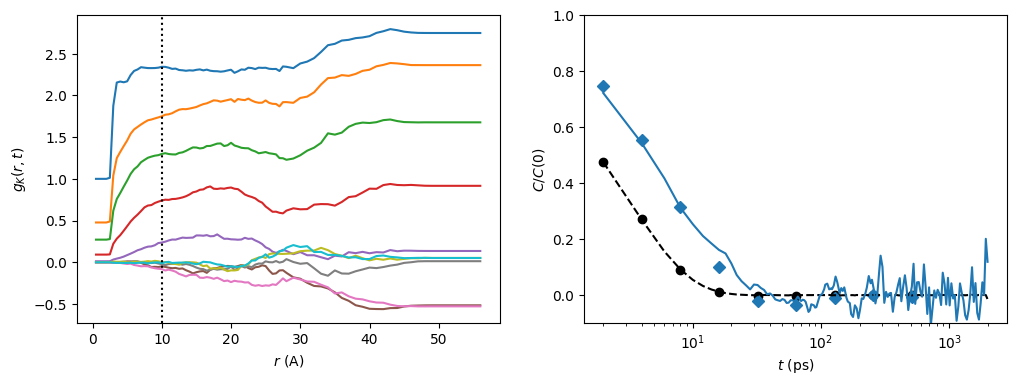

In [20]:
r_c = 10.
fig, axs = plt.subplots(1,2,figsize=(12,4))
for i, t_ in enumerate(t):
    axs[0].plot(r, gkrt[i, :])
    axs[1].plot(t_, gkrt[i, 0], 'ko')
    axs[1].plot(t_, np.interp(r_c, r, gkrt[i, :])/np.interp(r_c, r, gkrt[0, :]), 'D', c='C0')
plt.plot(t_self[1:], c_self[1:]/c_self[0], c='k', ls='--')
plt.plot(t_tot[1:], c_tot[1:]/c_tot[0], c='C0')
axs[0].axvline(r_c, ls=':', c='k')
axs[0].set_ylabel(r'$g_K(r, t)$')
axs[0].set_xlabel(r'$r$ (A)')
axs[1].set_xscale('log')
axs[1].set_ylim((-0.1,1))
axs[1].set_ylabel(r'$C/C(0)$')
axs[1].set_xlabel(r'$t$ (ps)')

### Exploiting the cavity method

To benefit from the advantages of the cavity method regarding the convergence of the dielectric response, it would require a shorter simulation (for instance 400 ps) with a smaller save step.